# DARL PPO con Stable-Baselines3

Este notebook implementa una aproximacion practica del POMDP de DARL. El agente observa senales resumidas de drift y costo historico, y elige una de cuatro acciones: defer, update features, update model o retrain all.

La demo usa escenarios sinteticos livianos para poder validar la integracion con SB3 en minutos, sin ejecutar TableShift ni reentrenar XGBoost en cada paso.


## 1. Imports y entorno


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "code" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import gymnasium
import matplotlib.pyplot as plt
import pandas as pd
import stable_baselines3
from matplotlib.colors import ListedColormap

EPISODE_LENGTH = 100
TRAINING_CHECKPOINTS = (
    0,
    500,
    1000,
    1500,
    2000,
    2500,
    3000,
)
PROGRESS_EVAL_EPISODES = 20
FINAL_EVAL_EPISODES = 50

print("gymnasium", gymnasium.__version__)
print("stable_baselines3", stable_baselines3.__version__)

gymnasium 1.3.0
stable_baselines3 2.9.0


## 2. Escenarios sinteticos DARL


In [4]:
from darl.rl.scenarios import make_synthetic_scenarios

scenarios = make_synthetic_scenarios(n_per_type=30, seed=42)
print(scenarios.shape)
scenarios.head()

(270, 22)


,drift_type,severity_label,severity,psi_mean,ks_mean,c2st_score,delta_auc,delta_f1,defer_auc_recovery,update_features_auc_recovery,...,defer_time_cost,defer_ram_cost,update_features_time_cost,update_features_ram_cost,update_model_time_cost,update_model_ram_cost,retrain_all_time_cost,retrain_all_ram_cost,has_covariate_signal,has_concept_signal
0,covariate,medium,0.60,0.152465,0.178880,0.115137,0.100414,0.079793,0.0,0.082339,...,0.0,0.0,0.28,0.22,0.45,0.35,1.0,1.0,1.0,0.0
1,concept,low,0.25,0.000000,0.010593,0.009279,0.050901,0.047865,0.0,0.009162,...,0.0,0.0,0.28,0.22,0.45,0.35,1.0,1.0,0.0,1.0
2,covariate,high,0.90,0.263402,0.309438,0.185301,0.154382,0.116459,0.0,0.126594,...,0.0,0.0,0.28,0.22,0.45,0.35,1.0,1.0,1.0,0.0
3,concept,medium,0.60,0.027151,0.019299,0.053796,0.177138,0.146955,0.0,0.031885,...,0.0,0.0,0.28,0.22,0.45,0.35,1.0,1.0,0.0,1.0
4,both,low,0.25,0.047039,0.088442,0.057356,0.179634,0.147451,0.0,0.044908,...,0.0,0.0,0.28,0.22,0.45,0.35,1.0,1.0,1.0,1.0


## 3. Entorno Gymnasium


In [5]:
from stable_baselines3.common.env_checker import check_env

from darl.rl.env import ACTION_NAMES, DarlUpdateEnv

env = DarlUpdateEnv(scenarios, episode_length=EPISODE_LENGTH, seed=42)
check_env(env, warn=True)

obs, info = env.reset(seed=42)
print("actions", ACTION_NAMES)
print("episode_length", EPISODE_LENGTH)
print("observation_shape", obs.shape)
print(obs)

actions ('defer', 'update_features', 'update_model', 'retrain_all')
episode_length 100
observation_shape (10,)
[0.25       0.06852271 0.07865053 0.04920282 0.04915385 0.02244974
 1.         0.         0.         0.        ]


## 4. Entrenamiento PPO


In [6]:
import importlib
import darl.rl.training as rl_training

rl_training = importlib.reload(rl_training)

model, training_progress_df = rl_training.training_progress(
    env,
    checkpoints=TRAINING_CHECKPOINTS,
    eval_episodes=PROGRESS_EVAL_EPISODES,
    seed=42,
)
print("PPO entrenado por checkpoints")

PPO entrenado por checkpoints


In [7]:
training_progress_df.round(4)

,timesteps,mean_reward,std_reward,mean_episode_reward,std_episode_reward,best_action_share,defer_share,update_features_share,update_model_share,retrain_all_share
0,0,0.0072,0.0461,0.7189,0.2510,0.9990,0.001,0.9990,0.0000,0.0
1,500,0.0071,0.0462,0.7143,0.2519,1.0000,0.000,1.0000,0.0000,0.0
2,1000,0.0072,0.0461,0.7161,0.2515,0.9990,0.000,0.9990,0.0010,0.0
3,1500,0.0325,0.0537,3.2548,0.4775,0.6525,0.000,0.6525,0.3475,0.0
4,2000,0.0325,0.0537,3.2548,0.4775,0.6525,0.000,0.6525,0.3475,0.0
5,2500,0.0325,0.0537,3.2548,0.4775,0.6525,0.000,0.6525,0.3475,0.0
6,3000,0.0323,0.0533,3.2260,0.4790,0.6015,0.000,0.6015,0.3985,0.0


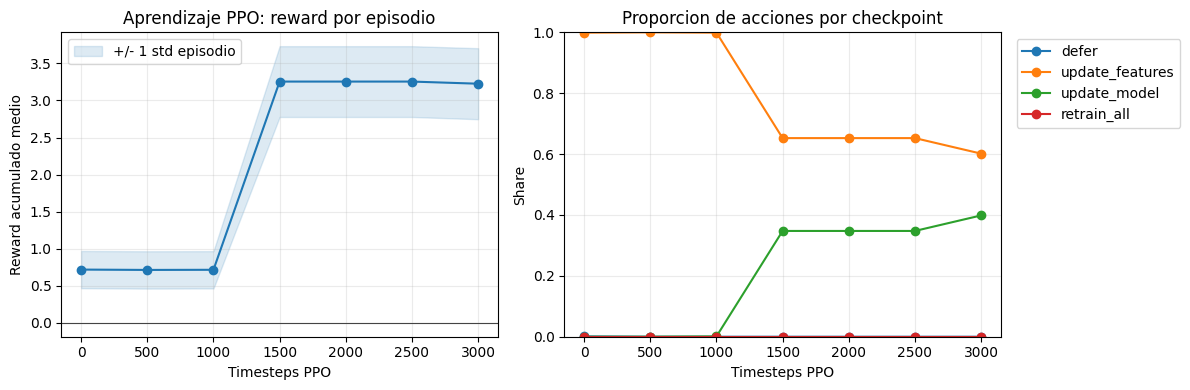

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    training_progress_df["timesteps"],
    training_progress_df["mean_episode_reward"],
    marker="o",
    color="#1f77b4",
)
axes[0].fill_between(
    training_progress_df["timesteps"],
    training_progress_df["mean_episode_reward"]
    - training_progress_df["std_episode_reward"],
    training_progress_df["mean_episode_reward"]
    + training_progress_df["std_episode_reward"],
    color="#1f77b4",
    alpha=0.15,
    label="+/- 1 std episodio",
)
axes[0].axhline(0, color="#444444", linewidth=0.8)
axes[0].set_title("Aprendizaje PPO: reward por episodio")
axes[0].set_xlabel("Timesteps PPO")
axes[0].set_ylabel("Reward acumulado medio")
axes[0].grid(alpha=0.25)
axes[0].legend()

share_cols = [f"{action}_share" for action in ACTION_NAMES]
for action, col in zip(ACTION_NAMES, share_cols):
    axes[1].plot(
        training_progress_df["timesteps"],
        training_progress_df[col],
        marker="o",
        label=action,
    )
axes[1].set_title("Proporcion de acciones por checkpoint")
axes[1].set_xlabel("Timesteps PPO")
axes[1].set_ylabel("Share")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
plt.show()

## 5. Evaluacion deterministica


In [9]:
eval_df = rl_training.evaluate_policy(model, env, n_episodes=FINAL_EVAL_EPISODES)
eval_df["relative_cost"] = (eval_df["time_cost"] + eval_df["ram_cost"]) / 2

episode_reward_df = rl_training.episode_reward_summary(eval_df)
step_reward_df = rl_training.step_reward_summary(eval_df)
action_by_drift_df = rl_training.normalized_action_distribution(eval_df, "drift_type")
action_by_severity_df = rl_training.normalized_action_distribution(eval_df, "severity")
reward_context_df = rl_training.reward_context_summary(eval_df)

evaluation_summary = pd.DataFrame(
    [
        {
            "episodes": FINAL_EVAL_EPISODES,
            "steps_per_episode": EPISODE_LENGTH,
            "mean_step_reward": eval_df["reward"].mean(),
            "mean_episode_reward": episode_reward_df["episode_reward"].mean(),
            "std_episode_reward": episode_reward_df["episode_reward"].std(ddof=0),
        }
    ]
)

action_summary = (
    eval_df["action"]
    .value_counts()
    .reindex(ACTION_NAMES, fill_value=0)
    .rename_axis("action")
    .reset_index(name="count")
)
action_summary["share"] = action_summary["count"] / len(eval_df)

print(f"evaluacion_final={FINAL_EVAL_EPISODES} episodios x {EPISODE_LENGTH} steps")
display(evaluation_summary.round(4))
display(action_summary.round(4))
display(reward_context_df.round(4))
display(eval_df.head(12))

evaluacion_final=50 episodios x 100 steps


,episodes,steps_per_episode,mean_step_reward,mean_episode_reward,std_episode_reward
0,50,100,0.0334,3.339,0.4155


,action,count,share
0,defer,0,0.0000
1,update_features,2993,0.5986
2,update_model,2007,0.4014
3,retrain_all,0,0.0000


,drift_type,severity,action,n,mean_reward,mean_auc_recovery,mean_relative_cost
0,both,high,update_features,272,0.0938,0.1563,0.25
1,both,high,update_model,283,0.0909,0.1909,0.40
2,both,low,update_features,531,-0.0186,0.0439,0.25
3,both,medium,update_features,515,0.0429,0.1054,0.25
4,concept,high,update_model,574,0.1219,0.2219,0.40
5,concept,low,update_model,584,-0.0400,0.0600,0.40
6,concept,medium,update_model,566,0.0476,0.1476,0.40
7,covariate,high,update_features,549,0.0620,0.1245,0.25
8,covariate,low,update_features,577,-0.0277,0.0348,0.25
9,covariate,medium,update_features,549,0.0217,0.0842,0.25


,episode,step,action,action_id,drift_type,severity,reward,auc_recovery,time_cost,ram_cost,done,relative_cost
0,0,0,update_features,1,covariate,low,-0.022194,0.040306,0.28,0.22,False,0.25
1,0,1,update_features,1,covariate,high,0.064870,0.127370,0.28,0.22,False,0.25
2,0,2,update_features,1,covariate,high,0.077124,0.139624,0.28,0.22,False,0.25
3,0,3,update_model,2,concept,medium,0.041184,0.141184,0.45,0.35,False,0.40
4,0,4,update_features,1,both,high,0.095424,0.157924,0.28,0.22,False,0.25
5,0,5,update_features,1,covariate,high,0.046041,0.108541,0.28,0.22,False,0.25
6,0,6,update_features,1,both,medium,0.045721,0.108221,0.28,0.22,False,0.25
7,0,7,update_features,1,covariate,high,0.065981,0.128481,0.28,0.22,False,0.25
8,0,8,update_model,2,both,high,0.086718,0.186718,0.45,0.35,False,0.40
9,0,9,update_features,1,covariate,low,-0.021988,0.040512,0.28,0.22,False,0.25


## 6. Visualizaciones de acciones y reward


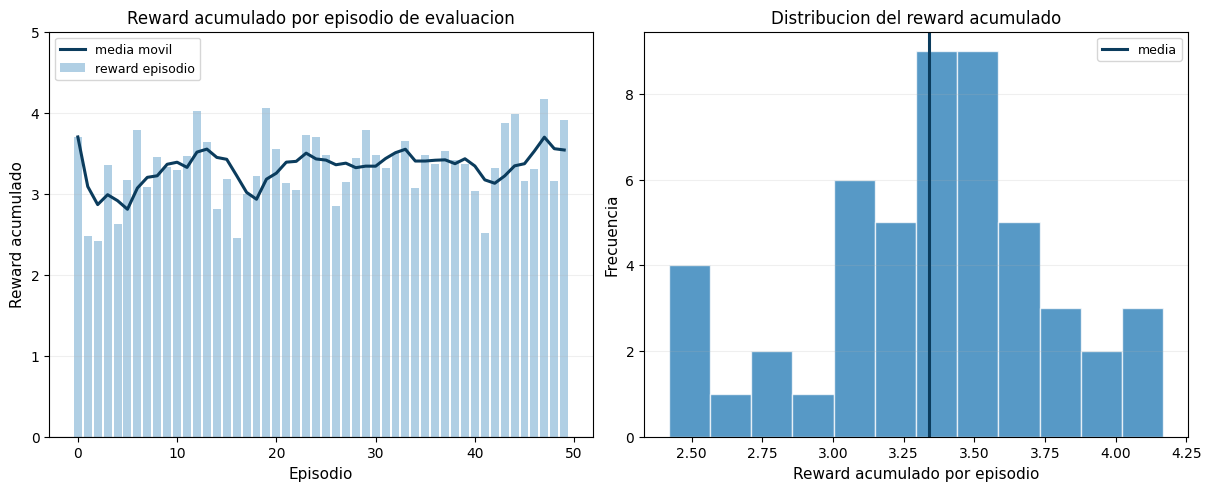

In [21]:
output_dir = PROJECT_ROOT / Path("outputs/figures")
thesis_figures_dir = PROJECT_ROOT / Path("thesis/figures/generated")
for directory in (output_dir, thesis_figures_dir):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
    }
)


def save_thesis_figure(fig, filename: str) -> None:
    """Guarda una figura vectorial para outputs y LaTeX."""
    for directory in (output_dir, thesis_figures_dir):
        fig.savefig(
            directory / filename,
            format="pdf",
            bbox_inches="tight",
            pad_inches=0.04,
            facecolor="white",
            metadata={"Creator": "darl_sb3_pomdp_demo.ipynb"},
        )


fig, ax = plt.subplots(figsize=(6.0, 4.3), constrained_layout=True)
ax.bar(
    episode_reward_df["episode"],
    episode_reward_df["episode_reward"],
    color="#1f77b4",
    alpha=0.35,
    label="reward episodio",
)
ax.plot(
    episode_reward_df["episode"],
    episode_reward_df["rolling_mean"],
    color="#0b3c5d",
    linewidth=2.2,
    label="media movil",
)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_title("Reward acumulado por episodio de evaluacion")
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward acumulado")
ax.set_ylim(0.0, 5.0)
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="upper left", frameon=True)
save_thesis_figure(fig, "ppo_reward_episodio.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(6.0, 4.3), constrained_layout=True)
ax.hist(
    episode_reward_df["episode_reward"],
    bins=12,
    color="#1f77b4",
    alpha=0.75,
    edgecolor="white",
)
ax.axvline(
    episode_reward_df["episode_reward"].mean(),
    color="#0b3c5d",
    linewidth=2.2,
    label="media",
)
ax.set_title("Distribucion del reward acumulado")
ax.set_xlabel("Reward acumulado por episodio")
ax.set_ylabel("Frecuencia")
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="upper right", frameon=True)
save_thesis_figure(fig, "ppo_reward_distribucion.pdf")
plt.show()


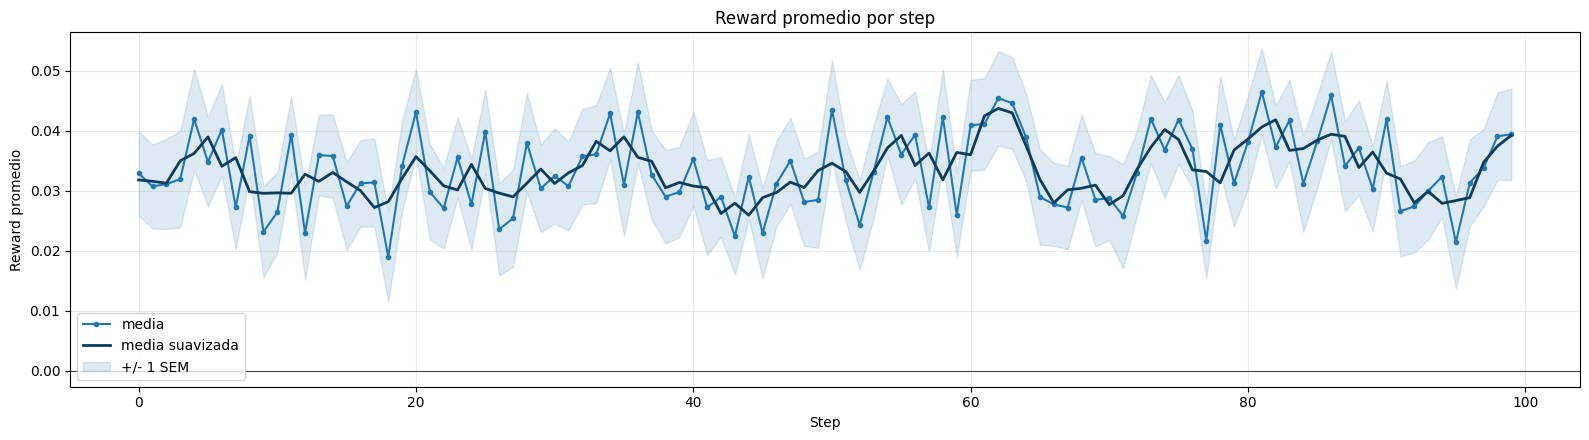

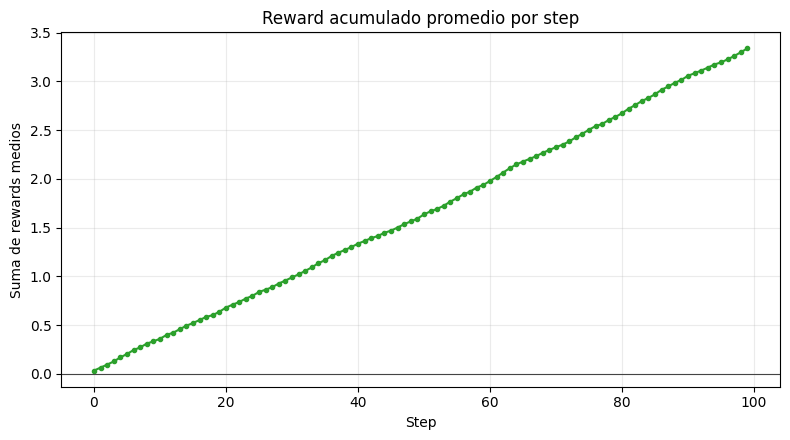

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
ax.plot(
    step_reward_df["step"],
    step_reward_df["mean_reward"],
    marker="o",
    markersize=3.5,
    linewidth=1.25,
    color="#1f77b4",
    label="media",
)
ax.plot(
    step_reward_df["step"],
    step_reward_df["smooth_reward"],
    color="#0b3c5d",
    linewidth=2.4,
    label="media suavizada",
)
ax.fill_between(
    step_reward_df["step"],
    step_reward_df["mean_reward"] - step_reward_df["sem_reward"],
    step_reward_df["mean_reward"] + step_reward_df["sem_reward"],
    color="#1f77b4",
    alpha=0.16,
    label="+/- 1 SEM",
)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_title("Reward promedio por step")
ax.set_xlabel("Step")
ax.set_ylabel("Reward promedio")
ax.grid(alpha=0.25)
ax.legend(loc="lower left", frameon=True)

save_thesis_figure(fig, "step_reward_summary.pdf")
plt.show()


fig, ax = plt.subplots(figsize=(11, 3.8), constrained_layout=True)
ax.plot(
    step_reward_df["step"],
    step_reward_df["cumulative_mean_reward"],
    marker="o",
    markersize=3,
    linewidth=1.8,
    color="#2ca02c",
)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_title("Reward acumulado promedio por step")
ax.set_xlabel("Step")
ax.set_ylabel("Suma de rewards medios")
ax.grid(alpha=0.25)
save_thesis_figure(fig, "cumulative_step_reward_summary.pdf")
plt.show()

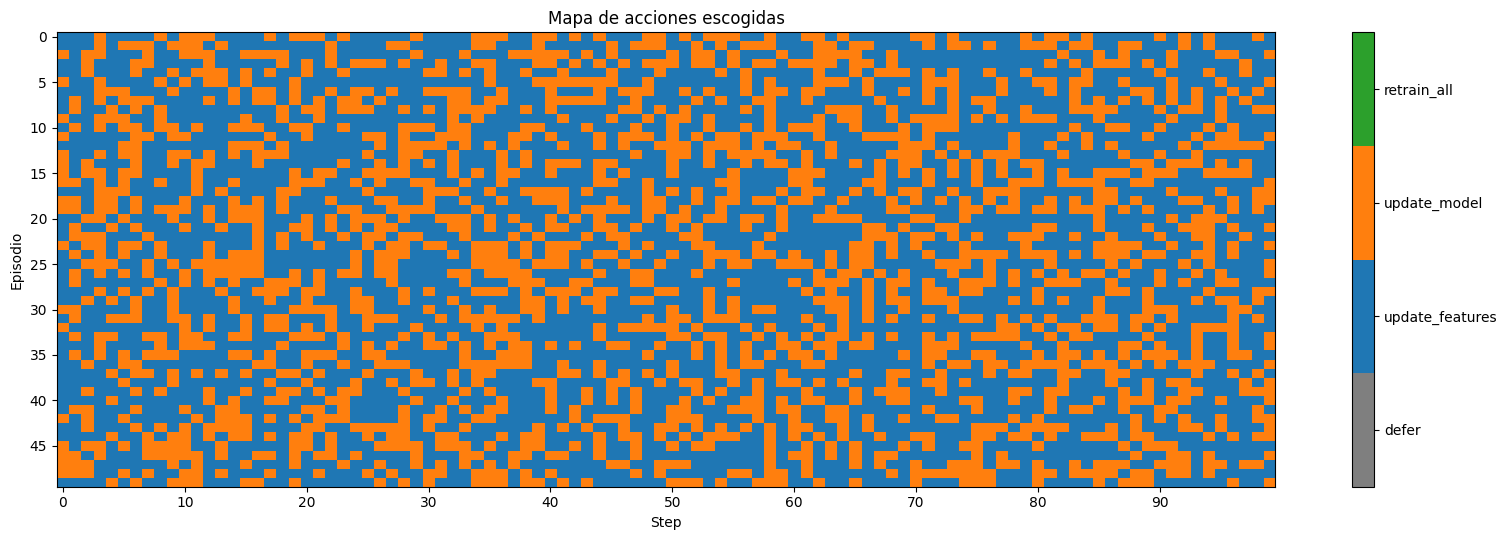

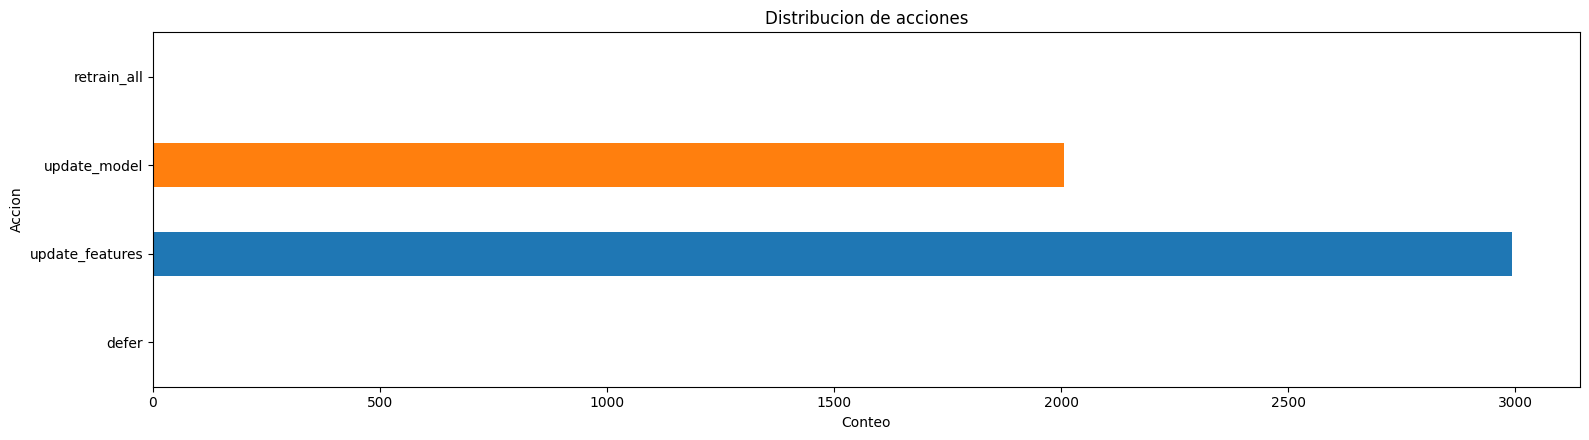

In [ ]:
action_palette = {
    "defer": "#7f7f7f",
    "update_features": "#1f77b4",
    "update_model": "#ff7f0e",
    "retrain_all": "#2ca02c",
}

action_grid = eval_df.pivot(
    index="episode", columns="step", values="action_id"
).sort_index()
cmap = ListedColormap([action_palette[action] for action in ACTION_NAMES])

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
im = ax.imshow(
    action_grid, aspect="auto", cmap=cmap, vmin=-0.5, vmax=len(ACTION_NAMES) - 0.5
)
ax.set_title("Mapa de acciones escogidas")
ax.set_xlabel("Step")
ax.set_ylabel("Episodio")
xtick_step = max(1, action_grid.shape[1] // 10)
xticks = list(range(0, action_grid.shape[1], xtick_step))
ax.set_xticks(xticks)
ax.set_xticklabels(action_grid.columns[xticks])
yticks = list(range(0, action_grid.shape[0], max(1, action_grid.shape[0] // 10)))
ax.set_yticks(yticks)
ax.set_yticklabels(action_grid.index[yticks])
cbar = fig.colorbar(im, ax=ax, ticks=range(len(ACTION_NAMES)))
cbar.ax.set_yticklabels(ACTION_NAMES)
save_thesis_figure(fig, "action_heatmap.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
action_summary.set_index("action")["count"].reindex(ACTION_NAMES).plot(
    kind="barh", ax=ax, color=[action_palette[action] for action in ACTION_NAMES]
)
ax.set_title("Distribucion de acciones")
ax.set_xlabel("Conteo")
ax.set_ylabel("Accion")
ax.grid(axis="x", alpha=0.25)
save_thesis_figure(fig, "action_distribution.pdf")
plt.show()

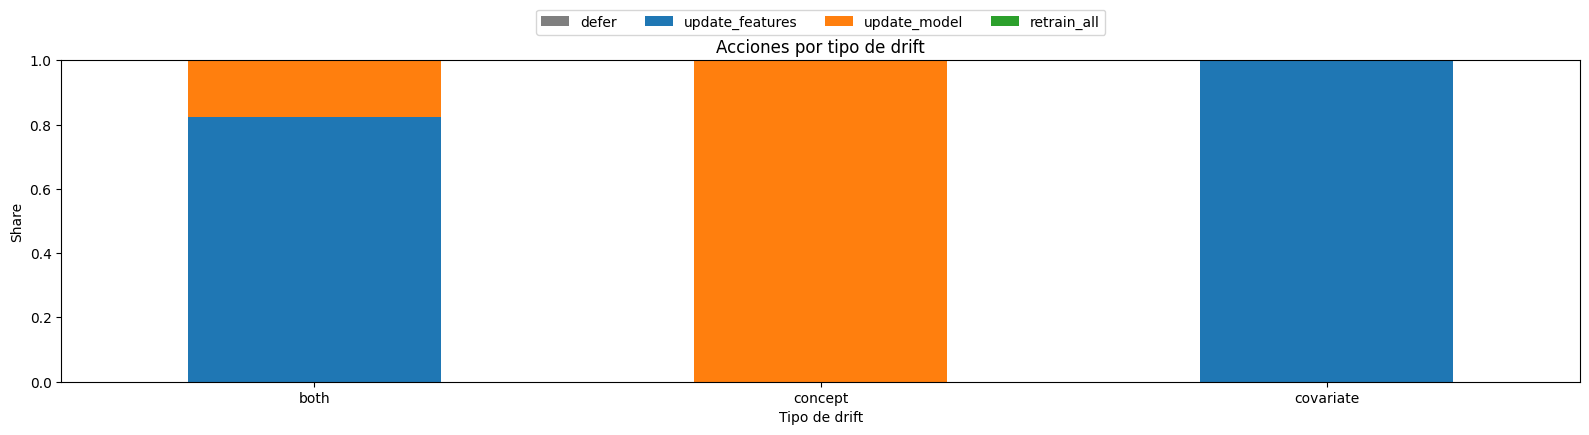

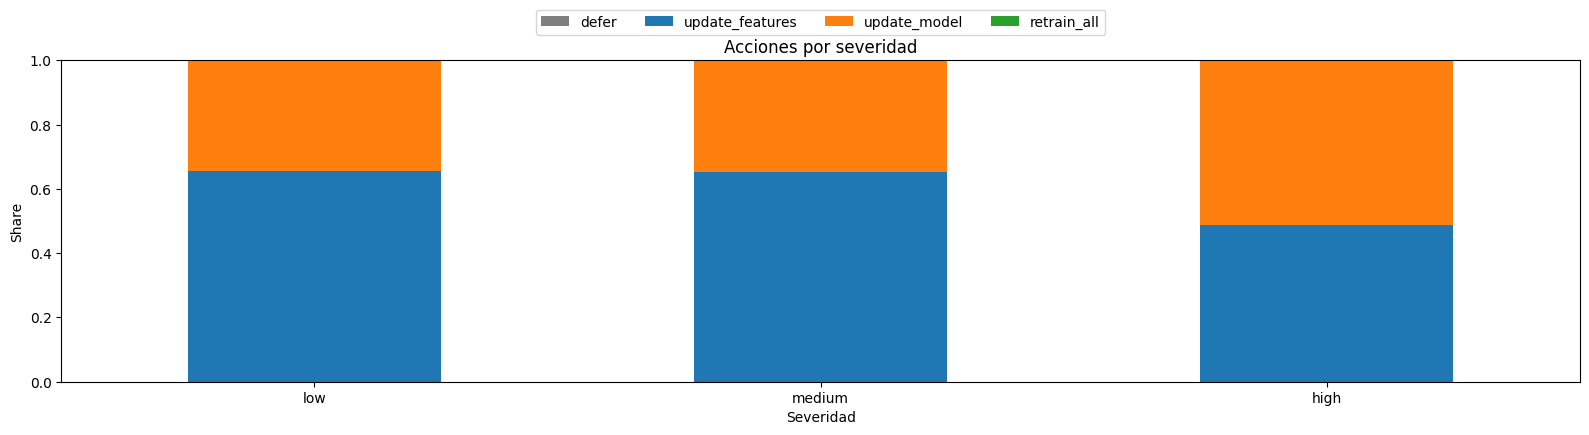

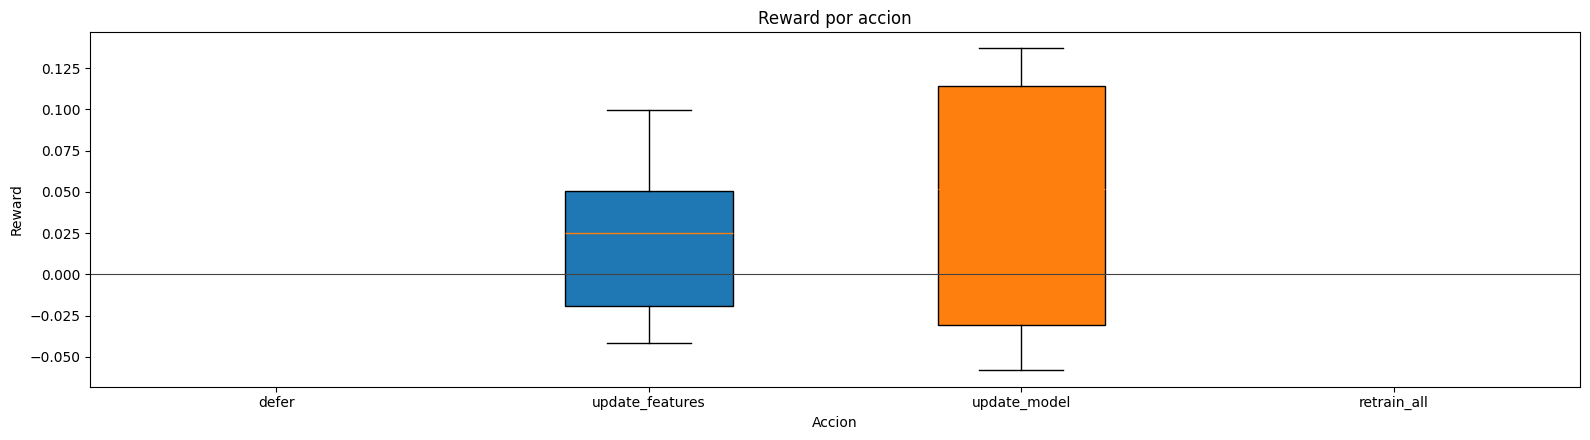

In [ ]:
plot_by_drift = action_by_drift_df.set_index("drift_type")
fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
plot_by_drift.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[action_palette[action] for action in ACTION_NAMES],
)
ax.set_title("Acciones por tipo de drift")
ax.set_xlabel("Tipo de drift")
ax.set_ylabel("Share")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=len(ACTION_NAMES),
    frameon=False,
)
save_thesis_figure(fig, "actions_by_drift.pdf")
plt.show()

severity_order = ["low", "medium", "high"]
plot_by_severity = action_by_severity_df.set_index("severity").reindex(severity_order)
fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
plot_by_severity.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[action_palette[action] for action in ACTION_NAMES],
)
ax.set_title("Acciones por severidad")
ax.set_xlabel("Severidad")
ax.set_ylabel("Share")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=len(ACTION_NAMES),
    frameon=False,
)
save_thesis_figure(fig, "actions_by_severity.pdf")
plt.show()

reward_groups = [
    eval_df.loc[eval_df["action"] == action, "reward"] for action in ACTION_NAMES
]
fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
box = ax.boxplot(reward_groups, tick_labels=ACTION_NAMES, patch_artist=True)
for patch, action in zip(box["boxes"], ACTION_NAMES):
    patch.set_facecolor(action_palette[action])
    patch.set_alpha(0.75)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_title("Reward por accion")
ax.set_xlabel("Accion")
ax.set_ylabel("Reward")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
save_thesis_figure(fig, "reward_by_action.pdf")
plt.show()

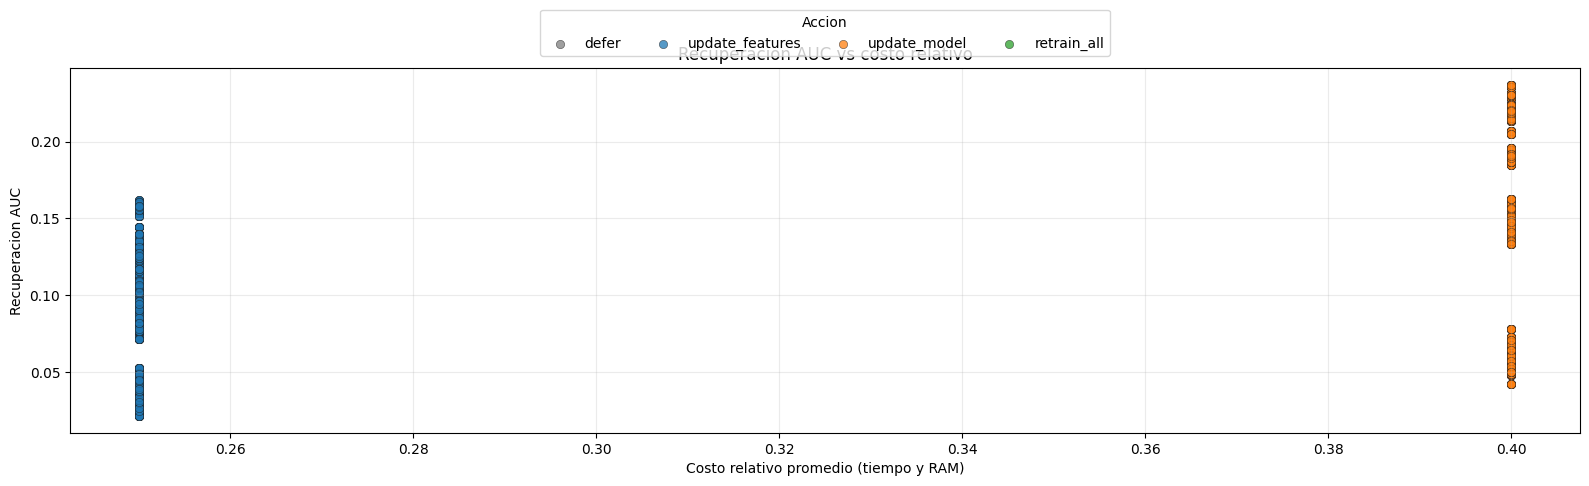

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for action in ACTION_NAMES:
    subset = eval_df[eval_df["action"] == action]
    ax.scatter(
        subset["relative_cost"],
        subset["auc_recovery"],
        label=action,
        color=action_palette[action],
        alpha=0.72,
        edgecolor="#222222",
        linewidth=0.35,
    )

ax.set_title("Recuperacion AUC vs costo relativo")
ax.set_xlabel("Costo relativo promedio (tiempo y RAM)")
ax.set_ylabel("Recuperacion AUC")
ax.grid(alpha=0.25)
ax.legend(
    title="Accion",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=len(ACTION_NAMES),
    frameon=False,
)
save_thesis_figure(fig, "auc_recovery_vs_cost.pdf")
plt.show()

## 7. Interpretacion para la tesis

Esta version no afirma resolver el POMDP completo con memoria recurrente. La aproximacion practica consiste en entregar a PPO un vector de observacion con metricas de drift, degradacion y costo historico. Eso permite validar la politica de decision DARL con una interfaz Gymnasium reproducible y despues reemplazar los escenarios sinteticos por episodios reales de TableShift.

Los graficos separan dos lecturas: el aprendizaje se interpreta contra los `timesteps` de PPO, mientras que el reward por `step` describe escenarios de evaluacion agregados. Por eso no se fuerza una curva monotona por step: cada step puede representar un caso de drift distinto dentro del episodio.
